<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/5.discharge_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Packages and Setup

In [1]:
# Import libraries for data manipulation, numerical computing, visualization, and geospatial analysis
import pandas as pd  # Data manipulation and analysis
import matplotlib.pyplot as plt  # Plot generation
import os  # Operating system interface for file operations
import seaborn as sns  # Statistical visualization

In [2]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 14  # Legend font size

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Set directory paths for output results and working data
exp_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Results"
wrk_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Water Period Definitions"

# Time Series Display Function

In [5]:
def prepare_time_series_plot(df, var, title, color_palette=None):
    """
    Create and display a time series plot with predictions and observations.
    
    Parameters:
    - df: DataFrame containing the time series data
    - var: Variable name to plot on y-axis
    - title: Title for the plot and output file
    - color_palette: Color scheme for water periods (default: uses predefined palette)
    """
    
    # Sort dataframe by time to ensure chronological order
    df = df.sort_values(by='time_start')

    # Create figure and axis with appropriate size for visibility
    fig, ax = plt.subplots(figsize=(16, 6))   

    # Plot the variable as a gray line to show overall trend
    ax.plot(df['time_start'], df[var], alpha=0.5,
                color='gray', linestyle='-.', linewidth=1)
    
    # Extract unique water periods and define color palette
    water_periods = sorted(df['water_period'].unique())
    if color_palette is None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Map each water period to a specific color
    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}

    # Plot observations separately for each water period with distinct colors
    for water_period in water_periods:
        subset = df[df['water_period'] == water_period]
        ax.plot(subset['time_start'], subset[var],
                marker='o', markersize=6, alpha=0.5,
                color=colors[water_period], linestyle='none',
                label=f'{water_period}')

    # Set x-axis label
    ax.set_xlabel('Date')
    
    # Set y-axis label and output directory based on variable type
    if "TSS" in var:
        ax.set_ylabel('TSS (mg/L)')
        directory = os.path.join(exp_directory, "TSS")
    elif "area" in var:
        ax.set_ylabel("Area (km$^2$)")
        directory = os.path.join(exp_directory, "Area")
    elif "chirps" in var:
        ax.set_ylabel("Accumulated Precipitation \n(total mm/Hidrological Period)")
        directory = os.path.join(exp_directory, "Precipitation")
    elif "discharge" in var:
        ax.set_ylabel("Mean Discharge \n(m$^3$/s)")
        directory = os.path.join(exp_directory, "Discharge")
    else:
        directory = exp_directory
    
    # Set title and legend
    ax.set_title(f"{title} vs Time")
    ax.legend(loc='best')

    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig(os.path.join(directory, f"{title}_time_series.jpg"), dpi=300)
    plt.show()
    plt.close()
    

# Import Water Period Definitions Based on Óbidos Water Level

In [6]:
# Load water period definitions generated from hydrological analysis
df_period_limits = pd.read_csv(os.path.join(wrk_directory, 'water_period_limits.csv')).drop(columns=['Unnamed: 0'])
df_period_limits['lim_previous'] = pd.to_datetime(df_period_limits['lim_previous'])
df_period_limits['lim_next'] = pd.to_datetime(df_period_limits['lim_next'])
df_period_limits

,lim_previous,lim_next,water_period,year,month
0,1968-06-30 12:00:00,1968-09-30 12:00:00,HW,1968,9
1,1968-09-30 12:00:00,1969-08-01 12:00:00,F,1969,8
2,1969-08-01 12:00:00,1970-02-07 18:00:00,LW,1970,2
3,1970-02-07 18:00:00,1970-04-24 06:00:00,R,1970,4
4,1970-04-24 06:00:00,1970-07-16 18:00:00,HW,1970,7
...,...,...,...,...,...
223,2024-11-23 00:00:00,2025-03-09 00:00:00,R,2025,3
224,2025-03-09 00:00:00,2025-06-09 00:00:00,HW,2025,6
225,2025-06-09 00:00:00,2025-09-09 00:00:00,F,2025,9
226,2025-09-09 00:00:00,2025-12-09 00:00:00,LW,2025,12


# Import Óbidos Discharge Data

## Data Source Information
**Agência Nacional de Águas (ANA)** - Brazilian National Water Agency

**Sistema de Informações Hidrológicas (SIH)** - Hydrological Information System - Web Version

**Station Code: 17050001** - Óbidos Discharge Monitoring Station

In [7]:
# import discharge database     

df = pd.read_csv(r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\HidroWeb\17050001_Vazoes.csv')     

df = df[['Data', 'Vazao01', 'Vazao02', 'Vazao03',  'Vazao04', 'Vazao05', 'Vazao06', 'Vazao07', 'Vazao08', 'Vazao09',
         'Vazao10', 'Vazao11', 'Vazao12', 'Vazao13', 'Vazao14', 'Vazao15',
         'Vazao16', 'Vazao17', 'Vazao18', 'Vazao19', 'Vazao20', 'Vazao21',
           'Vazao22', 'Vazao23', 'Vazao24', 'Vazao25', 'Vazao26', 'Vazao27',
          'Vazao28', 'Vazao29', 'Vazao30', 'Vazao31']].copy()

In [8]:
# Restructure data from monthly format (one row per month with 31 columns) 
# to daily format (one row per day)
vazao = []  # List to store discharge values
data = []   # List to store corresponding dates

# Iterate through each month (row) and each day (column)
for row in range(df.shape[0]):
    for column in df.columns[1:]:  # Skip the 'Data' column
        dados = df.iloc[row]

        # Extract day from column name (e.g., 'Vazao01' -> '01')
        dia = str(column[-2:])
        
        # Extract year and month from date string in Brazilian format (DD/MM/YYYY)
        ano = str(dados['Data'][-4:])  # Last 4 characters are year
        mes = str(dados['Data'][3:-5])  # Month is between position 3 and -5

                

        # Create ISO format date string (YYYY-MM-DD)        vazao.append(dados[column])

        data.append(f"{ano}-{mes}-{dia}")        # Store corresponding discharge value
        vazao.append(dados[column])

In [9]:
# Create index lists for merging the reshuffled data
idx = list(range(len(data)))  # Sequential index for both arrays

# Create dictionary with discharge values and index
d_vazao = {"vazao": vazao, 'idx': idx}

# Create dictionary with dates and index
d_datas = {"Data": data, 'idx': idx}


# Merge the two dataframes on index and remove the index columndf_vazao

df_vazao = pd.DataFrame(d_vazao).merge(pd.DataFrame(d_datas), how='inner', on='idx').drop(columns='idx').dropna()# Display the restructured daily discharge dataframe



# Convert date column to proper datetime format for temporal processingdf_vazao = df_vazao.sort_values("Data").reset_index(drop=True)

df_vazao['Data'] = pd.to_datetime(df_vazao['Data'])# Sort by date and reset index for clean sequential ordering



# Filter data to start from 1985 (CHIRPS dataset availability)
# df_vazao = df_vazao.loc[(df_vazao['Data'] >= "1984-01-01")].copy()

In [10]:
df_vazao

,vazao,Data
0,233212.3,2025-07-01
1,233598.1,2025-07-02
2,233212.3,2025-07-03
3,233855.4,2025-07-04
4,233598.1,2025-07-05
...,...,...
21416,117000.0,1968-01-27
21417,117000.0,1968-01-28
21418,118000.0,1968-01-29
21419,119000.0,1968-01-30


# Calculate Mean Discharge Values by Hydrological Period

In [11]:
# Calculate mean discharge for each hydrological period
period_mean = []  # List to store mean discharge values
wp = []           # List to store water period classifications
init = []         # List to store period start dates
end = []          # List to store period end dates

# Iterate through each defined hydrological period
for i in range(df_period_limits.shape[0]):
    # Get period definition (start date, end date, water period classification)
    x = df_period_limits.iloc[i]
    

    # Filter discharge data for the current period date range    

    period = df_vazao.loc[(df_vazao['Data'] >= x['lim_previous']) & (df_vazao['Data'] <= x['lim_next'])].copy()   
        

    # Calculate and store mean discharge for the period    end.append(period['Data'].max())

    period_mean.append(float(period['vazao'].mean()))    
    # print(len(period['vazao']))
    # Store the actual data date range (may differ from period limits if data gaps exist)
    init.append(x['lim_previous'])
    end.append(x['lim_next'])
     # Store water period classification (R=Rising, F=Falling, HW=High Water, LW=Low Water)
    wp.append(x['water_period'])

        

In [12]:
# Create dataframe with period statistics from the collected data
df_period_vazao = pd.DataFrame({
    "water_period": wp,           # Hydrological period classification
    "time_start": init,           # Actual period start date (from data)
    'time_finish': end,           # Actual period end date (from data)
    "mean_discharge": period_mean # Mean discharge (m³/s) for the period
})


# Sort by start date, remove rows with missing values, and reset index for clean orderingdf_period_vazao

df_period_vazao = df_period_vazao.sort_values("time_start").reset_index(drop=True)# Display the period discharge statistics dataframe
df_period_vazao.loc[df_period_vazao['mean_discharge'].isna()]

,water_period,time_start,time_finish,mean_discharge
226,LW,2025-09-09,2025-12-09,NaN
227,R,2025-12-09,2026-01-01,NaN


In [13]:
# Export the complete time series dataframe to a CSV file for future reference and analysis
df_period_vazao.to_csv(os.path.join(exp_directory, 'discharge_time_series.csv'))

# Visualize River Discharge Time Series Data

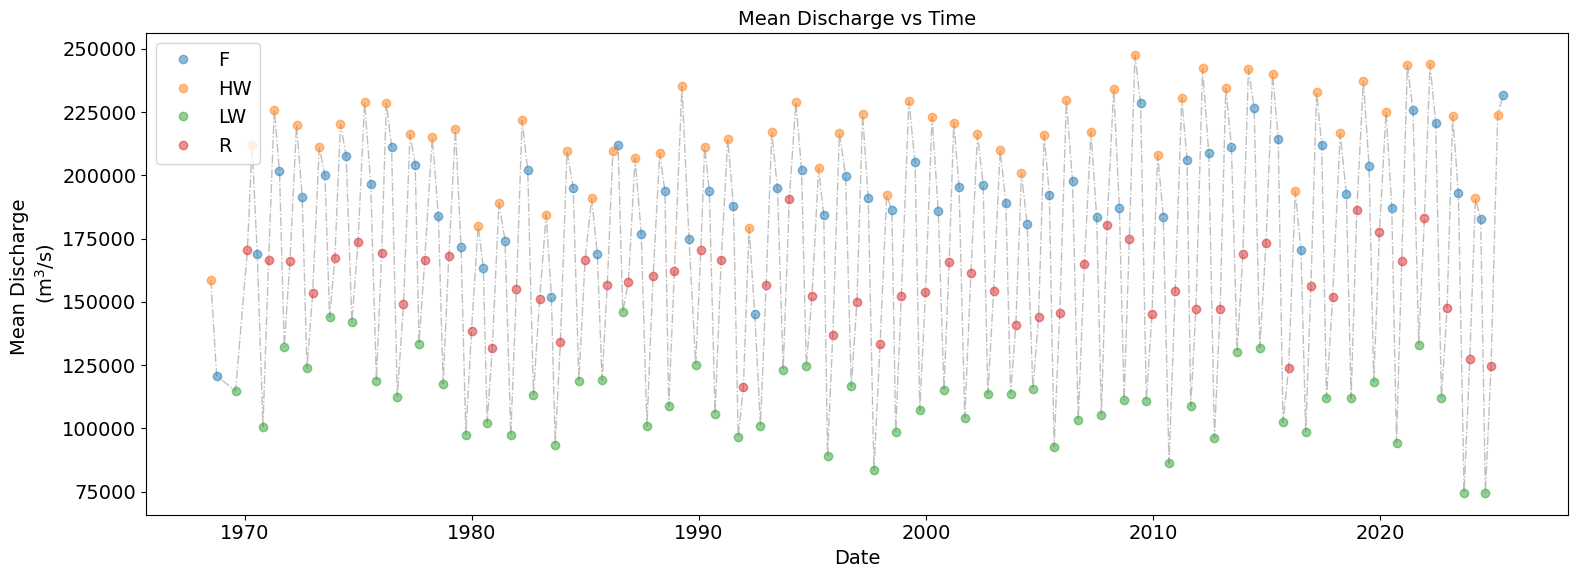

In [14]:
# Create and display time series plot for local watershed mean discharge over time
prepare_time_series_plot(df_period_vazao, 'mean_discharge', "Mean Discharge")

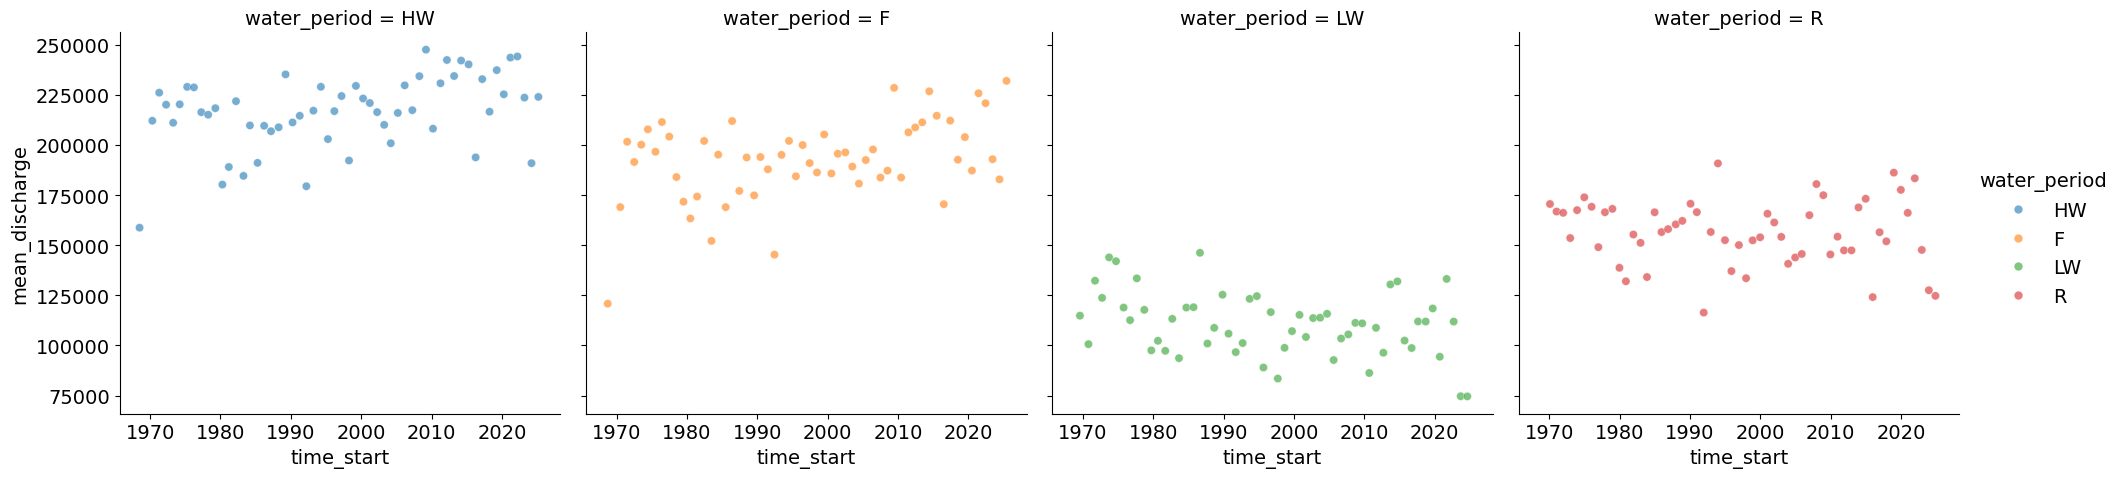

In [15]:
# Create separate scatter plots showing local discharge for each water period over time
sns.relplot(data=df_period_vazao, x='time_start', y='mean_discharge', alpha=.6, hue='water_period', col='water_period')